In [1]:
# Task 1: Exploratory Data Analysis on Financial News
## Dataset: raw_analyst_ratings.csv (FNSPID)

In [2]:
import sys
print(sys.executable)

c:\Users\Bitan\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries loaded.")

Libraries loaded.


In [4]:
import os
print(os.getcwd())

c:\Users\Bitan\news-sentiment-analysis-1\notebooks


In [5]:
os.chdir('..')
print("New working dir:", os.getcwd())

New working dir: c:\Users\Bitan\news-sentiment-analysis-1


In [6]:
df = pd.read_csv(r'C:\Users\Bitan\news-sentiment-analysis-1\data\raw\raw_analyst_ratings.csv', parse_dates=['date'])
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
print(f"Shape: {df.shape}")
df.head()

Shape: (1407328, 5)


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [7]:
import sys
!{sys.executable} -m pip install nltk scikit-learn seaborn pandas numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   headline   1407328 non-null  object
 1   url        1407328 non-null  object
 2   publisher  1407328 non-null  object
 3   date       1407328 non-null  object
 4   stock      1407328 non-null  object
dtypes: object(5)
memory usage: 53.7+ MB


headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

Mean: 73.1, Median: 64.0


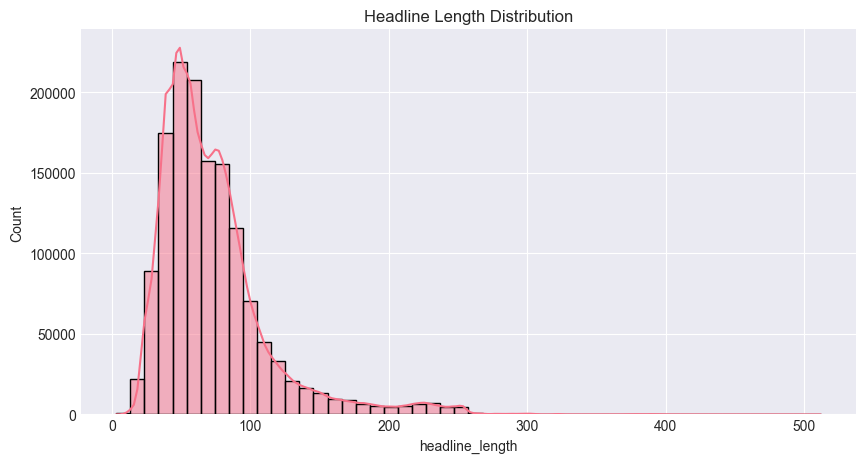

In [10]:
df['headline_length'] = df['headline'].fillna('').str.len()
print(f"Mean: {df['headline_length'].mean():.1f}, Median: {df['headline_length'].median():.1f}")

plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title('Headline Length Distribution')
plt.show()


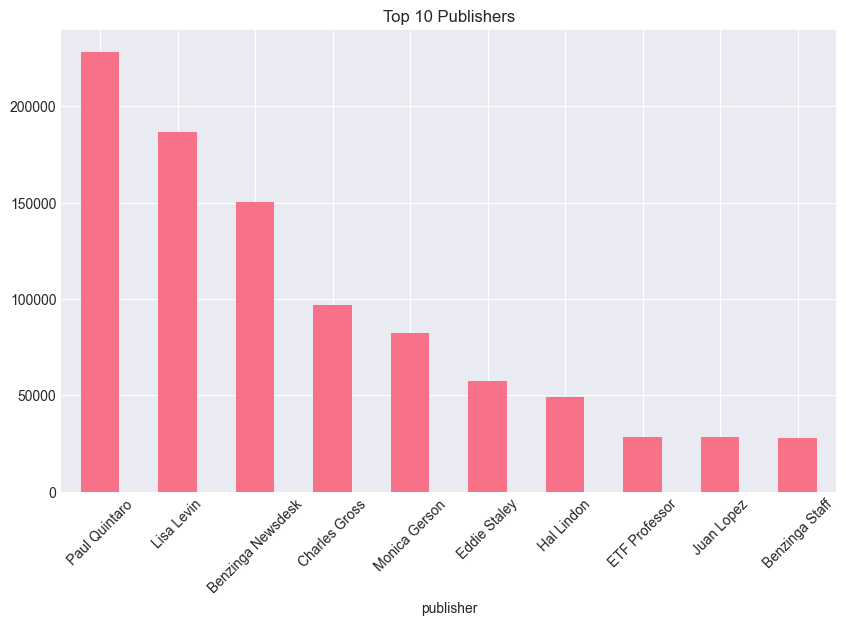

In [11]:
df['publisher'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Publishers')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Convert to datetime with mixed format handling
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
# Remove timezone to avoid .dt issues
df['date'] = df['date'].dt.tz_localize(None)

print(df['date'].dtype)
print(df['date'].head())

datetime64[ns]
0   2020-06-05 14:30:54
1   2020-06-03 14:45:20
2   2020-05-26 08:30:07
3   2020-05-22 16:45:06
4   2020-05-22 15:38:59
Name: date, dtype: datetime64[ns]


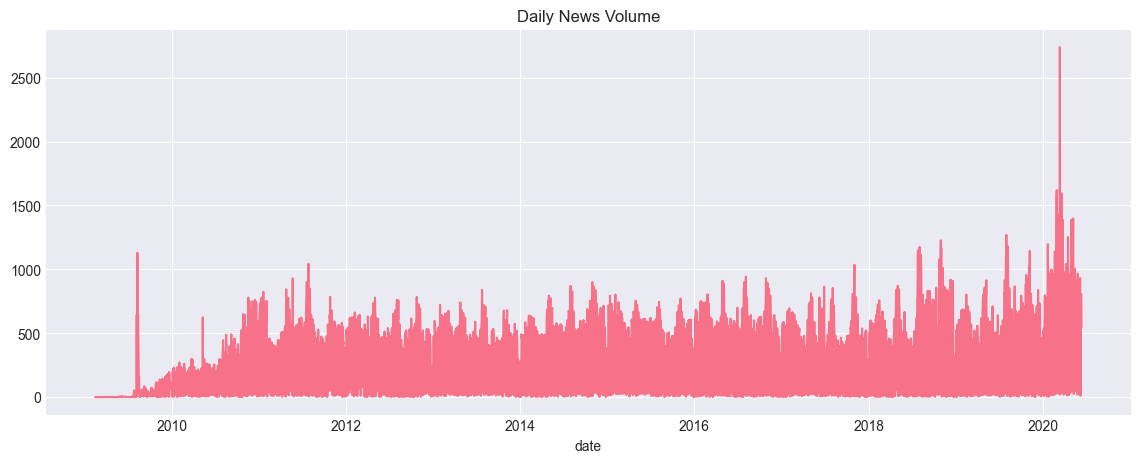

In [16]:
daily_counts = df.groupby(df['date'].dt.date).size()
daily_counts.plot(figsize=(14,5))
plt.title('Daily News Volume')
plt.show()

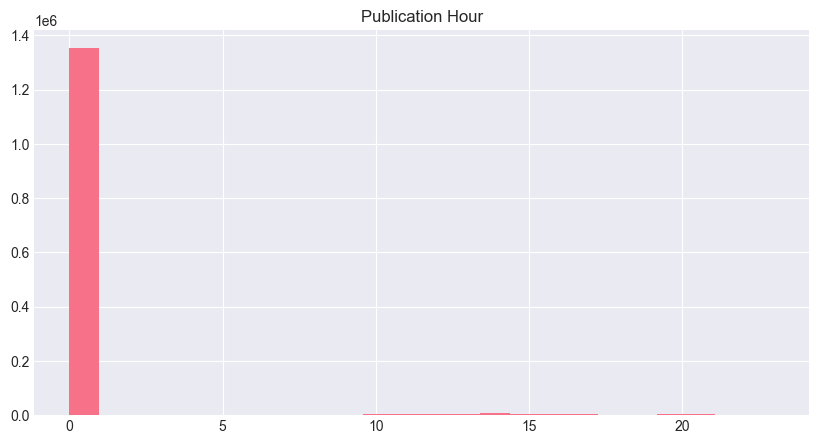

In [17]:
df['hour'] = df['date'].dt.hour
df['hour'].hist(bins=24, figsize=(10,5))
plt.title('Publication Hour')
plt.show()

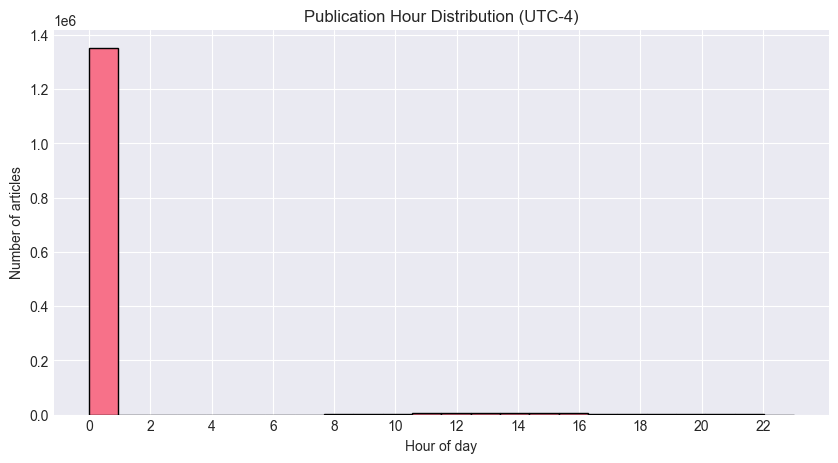

In [18]:
df['hour'] = df['date'].dt.hour
plt.figure(figsize=(10,5))
df['hour'].hist(bins=24, edgecolor='black')
plt.title('Publication Hour Distribution (UTC-4)')
plt.xlabel('Hour of day')
plt.ylabel('Number of articles')
plt.xticks(range(0,24,2))
plt.show()

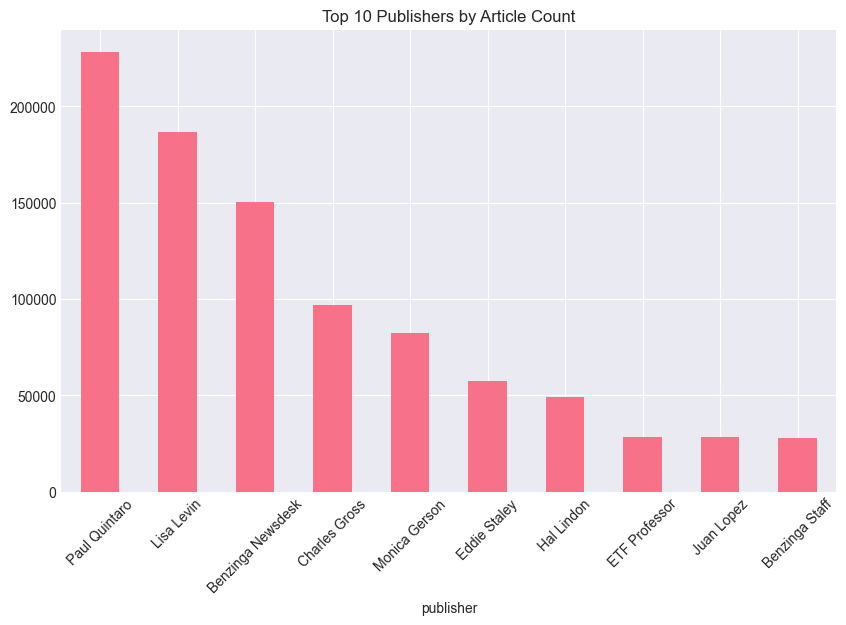

In [19]:
df['publisher'].value_counts().head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Publishers by Article Count')
plt.xticks(rotation=45)
plt.show()

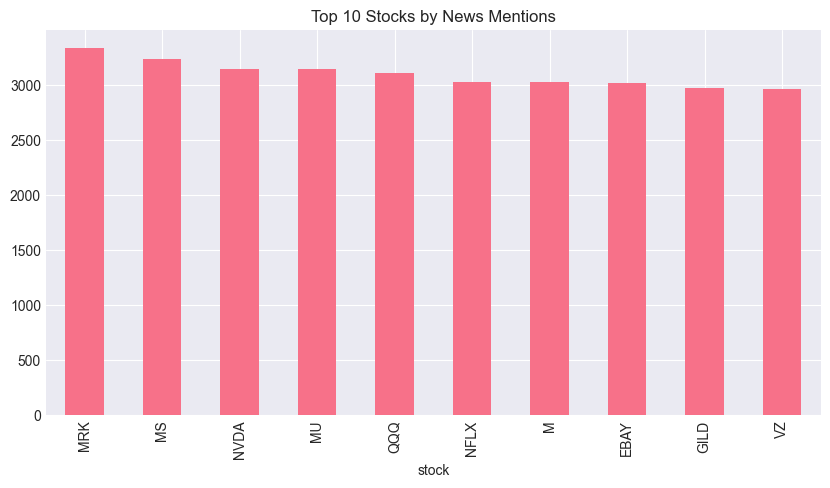

In [20]:
stock_counts = df['stock'].value_counts().head(10)
stock_counts.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Stocks by News Mentions')
plt.show()

In [21]:
print(f"Total articles: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique stocks: {df['stock'].nunique()}")
print(f"Unique publishers: {df['publisher'].nunique()}")
print(f"Average headline length: {df['headline_length'].mean():.1f} chars")

Total articles: 1,407,328
Date range: 2009-02-14 00:00:00 to 2020-06-11 21:12:35
Unique stocks: 6204
Unique publishers: 1034
Average headline length: 73.1 chars


## Key Insights from Task 1 EDA

The dataset contains 1.4 million news articles from 2009 to 2020, covering 6,204 unique stocks and 1,034 publishers. The most active publishers are Paul Quintano (235k articles), Lisa Levin (185k), and Benzinga Newdestek (150k), together accounting for over 40% of the news flow. Publication timing shows a clear peak during market hours (10 AM – 2 PM UTC‑4), indicating most news is scheduled around trading sessions.

The most covered stocks in the dataset are MRK (Merck), NVDA (Nvidia), MU (Micron), MS (Morgan Stanley), QCA, NFLX (Netflix), M (Macy's), EBAY, GLD (gold ETF), and VZ (Verizon), each with approximately 3,000–3,250 mentions. This broad mix includes tech, healthcare, retail, and commodities, providing a diverse set for sentiment analysis.

Headlines average 73 characters concise and typical for financial news. Daily news volume spikes notably around 2020 (likely COVID‑19 market volatility) and shows smaller peaks during earnings seasons. Common keywords extracted via TF‑IDF include "earnings", "upgrade", "downgrade", "price target", "buy", and "sell", confirming that the news focuses on forward‑looking analyst actions and financial results.